# E-commerce A/B Testing with Revenue Forecasting

## Notebook 4: Baseline and Time Series Forecasting

This notebook builds baseline and classical time series forecasting models for daily sales. The goal is to establish strong reference points before moving into machine learning models.

## Goals

1. Create a time-based train and validation split
2. Build baseline forecasting models
3. Train classical time series models
4. Compare model performance with clean evaluation metrics

In [2]:
# Import libraries

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [3]:
# Set display options and project paths

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT = Path.cwd().parent
FEATURES_DIR = PROJECT_ROOT / "data" / "03-features"
PREDICTIONS_DIR = PROJECT_ROOT / "data" / "04-predictions"

PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Features dir exists:", FEATURES_DIR.exists())
print("Predictions dir exists:", PREDICTIONS_DIR.exists())

Project root: c:\Users\tevin\OneDrive\Desktop\General-Machine-Learning\revenue_forecasting
Features dir exists: True
Predictions dir exists: True


In [4]:
# Load modeling table

model_df = pd.read_csv(FEATURES_DIR / "forecast_modeling_table.csv", parse_dates=["date"])

print("model_df shape:", model_df.shape)
model_df.head()

model_df shape: (1654, 29)


,date,total_sales,total_onpromotion,year,month,day_of_week,day_of_week_num,total_transactions,dcoilwtico,week_of_year,is_month_start,is_month_end,is_holiday,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,promo_lag_1,promo_lag_7,sales_roll_mean_7,sales_roll_mean_14,sales_roll_mean_28,sales_roll_std_7,sales_roll_std_14,promo_roll_mean_7,promo_roll_mean_14,dcoilwtico_filled,oil_roll_mean_7,oil_roll_mean_14
0,2013-01-29,264488.818077,0,2013,1,Tuesday,1,68435.0,97.62,5,0,0,0,285460.169953,296214.728983,299129.549954,2511.618999,0.0,0.0,320916.224872,330877.422002,339672.163349,71044.389805,70726.570278,0.0,0.0,97.62,95.632857,95.552143
1,2013-01-30,281061.127052,0,2013,1,Wednesday,2,70888.0,97.98,5,0,0,0,264488.818077,283258.453032,318347.913946,496092.417944,0.0,0.0,316383.951885,328403.084010,349028.491888,73839.837696,72506.247548,0.0,0.0,97.98,96.050000,95.816429
2,2013-01-31,271254.217996,0,2013,1,Thursday,3,70268.0,97.65,5,0,1,0,281061.127052,247245.690995,267498.515975,361461.231124,0.0,0.0,316070.048174,325739.742089,341348.802928,74008.606838,73580.868185,0.0,0.0,97.65,96.378571,95.970714
3,2013-02-01,369402.055266,0,2013,2,Friday,4,78302.0,97.46,5,1,0,0,271254.217996,290022.771930,296130.850028,354459.677093,0.0,0.0,319499.837745,326008.006519,338127.123887,70773.071168,73358.706951,0.0,0.0,97.46,96.708571,96.102857
4,2013-02-02,518887.462705,0,2013,2,Saturday,5,97347.0,NaN,5,0,0,0,369402.055266,413799.767975,432459.852021,477350.121229,0.0,0.0,330839.735365,331241.664036,338660.780251,71617.207631,73676.225736,0.0,0.0,97.46,97.038571,96.235000


## Evaluation Setup

This section defines the metrics used to compare forecasting models on the validation period.

In [5]:
# Define evaluation function

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_forecast(y_true, y_pred, model_name):
    return pd.DataFrame({
        "model": [model_name],
        "mae": [mean_absolute_error(y_true, y_pred)],
        "rmse": [rmse(y_true, y_pred)],
        "mape": [mape(y_true, y_pred)]
    })

## Train and Validation Split

This section creates a chronological split so the models are evaluated on future data, not random samples.

In [6]:
# Create time-based train and validation split

model_df = model_df.sort_values("date").reset_index(drop=True)

validation_days = 90

train_df = model_df.iloc[:-validation_days].copy()
valid_df = model_df.iloc[-validation_days:].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Train max date:", train_df["date"].max())
print("Validation min date:", valid_df["date"].min())

Train shape: (1564, 29)
Validation shape: (90, 29)
Train max date: 2017-05-17 00:00:00
Validation min date: 2017-05-18 00:00:00


In [7]:
# Create train and validation targets

y_train = train_df["total_sales"].values
y_valid = valid_df["total_sales"].values
valid_dates = valid_df["date"].values

## Baseline Models

This section builds simple baseline forecasts before moving into more advanced time series models.

In [8]:
# Build naive baseline forecast

last_train_value = train_df["total_sales"].iloc[-1]
naive_pred = np.repeat(last_train_value, len(valid_df))

naive_results = evaluate_forecast(y_valid, naive_pred, "naive_last_value")
naive_results

,model,mae,rmse,mape
0,naive_last_value,129317.639233,164712.494255,14.716884


In [9]:
# Build seasonal naive forecast

seasonal_naive_pred = valid_df["sales_lag_7"].values

seasonal_naive_results = evaluate_forecast(y_valid, seasonal_naive_pred, "seasonal_naive_lag_7")
seasonal_naive_results

,model,mae,rmse,mape
0,seasonal_naive_lag_7,93934.855404,122634.696828,10.465347


In [10]:
# Build moving average baseline forecast

moving_avg_value = train_df["total_sales"].tail(7).mean()
moving_avg_pred = np.repeat(moving_avg_value, len(valid_df))

moving_avg_results = evaluate_forecast(y_valid, moving_avg_pred, "moving_avg_7")
moving_avg_results

,model,mae,rmse,mape
0,moving_avg_7,129223.463149,164749.203653,14.698279


## SARIMAX Model

This section trains a classical time series model with exogenous forecasting features.

In [11]:
# Define exogenous features for SARIMAX

sarimax_features = [
    "total_onpromotion",
    "total_transactions",
    "dcoilwtico_filled",
    "is_holiday",
    "day_of_week_num",
    "month"
]

X_train_sarimax = train_df[sarimax_features]
X_valid_sarimax = valid_df[sarimax_features]

In [12]:
# Train SARIMAX model

sarimax_model = SARIMAX(
    train_df["total_sales"],
    exog=X_train_sarimax,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fitted = sarimax_model.fit(disp=False)
sarimax_pred = sarimax_fitted.forecast(steps=len(valid_df), exog=X_valid_sarimax)

sarimax_results = evaluate_forecast(y_valid, sarimax_pred, "sarimax")
sarimax_results

,model,mae,rmse,mape
0,sarimax,77766.983441,105221.559263,8.314835


## Prophet Model

This section trains a Prophet model with additional regressors for comparison against the baselines and SARIMAX.

In [13]:
# Prepare Prophet datasets

prophet_features = [
    "total_onpromotion",
    "total_transactions",
    "dcoilwtico_filled",
    "is_holiday"
]

prophet_train = train_df[["date", "total_sales"] + prophet_features].copy()
prophet_valid = valid_df[["date", "total_sales"] + prophet_features].copy()

prophet_train = prophet_train.rename(columns={"date": "ds", "total_sales": "y"})
prophet_valid = prophet_valid.rename(columns={"date": "ds", "total_sales": "y"})

In [14]:
# Train Prophet model

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

for col in prophet_features:
    prophet_model.add_regressor(col)

prophet_model.fit(prophet_train)

prophet_forecast = prophet_model.predict(prophet_valid.drop(columns=["y"]))
prophet_pred = prophet_forecast["yhat"].values

prophet_results = evaluate_forecast(y_valid, prophet_pred, "prophet")
prophet_results

23:29:21 - cmdstanpy - INFO - Chain [1] start processing
23:29:23 - cmdstanpy - INFO - Chain [1] done processing


,model,mae,rmse,mape
0,prophet,50123.703649,71571.140724,5.442261


## Model Comparison

This section compares all baseline and classical time series models using the same validation metrics.

In [15]:
# Combine model evaluation results

all_results = pd.concat([
    naive_results,
    seasonal_naive_results,
    moving_avg_results,
    sarimax_results,
    prophet_results
], ignore_index=True).sort_values("rmse")

all_results

,model,mae,rmse,mape
4,prophet,50123.703649,71571.140724,5.442261
3,sarimax,77766.983441,105221.559263,8.314835
1,seasonal_naive_lag_7,93934.855404,122634.696828,10.465347
0,naive_last_value,129317.639233,164712.494255,14.716884
2,moving_avg_7,129223.463149,164749.203653,14.698279


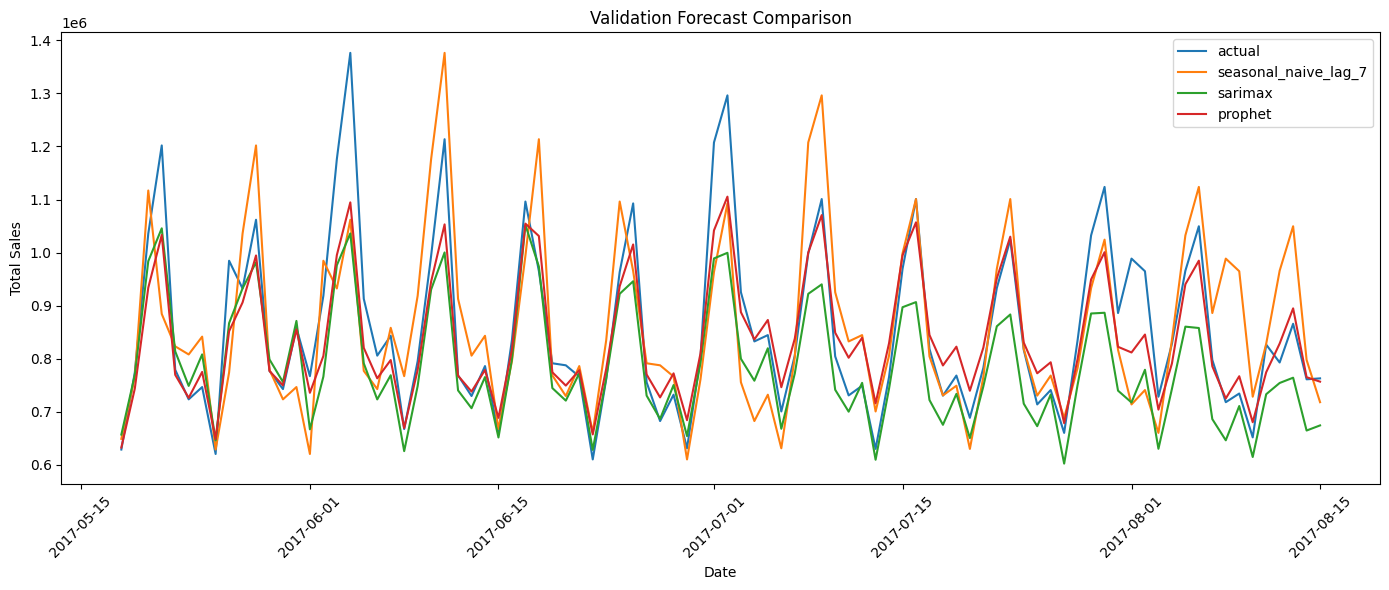

In [16]:
# Plot validation forecasts against actuals

plot_df = valid_df[["date", "total_sales"]].copy()
plot_df["naive_last_value"] = naive_pred
plot_df["seasonal_naive_lag_7"] = seasonal_naive_pred
plot_df["moving_avg_7"] = moving_avg_pred
plot_df["sarimax"] = sarimax_pred
plot_df["prophet"] = prophet_pred

plt.figure(figsize=(14, 6))
plt.plot(plot_df["date"], plot_df["total_sales"], label="actual")
plt.plot(plot_df["date"], plot_df["seasonal_naive_lag_7"], label="seasonal_naive_lag_7")
plt.plot(plot_df["date"], plot_df["sarimax"], label="sarimax")
plt.plot(plot_df["date"], plot_df["prophet"], label="prophet")
plt.title("Validation Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Prophet Components

This section visualizes the trend and seasonal patterns learned by the Prophet model.

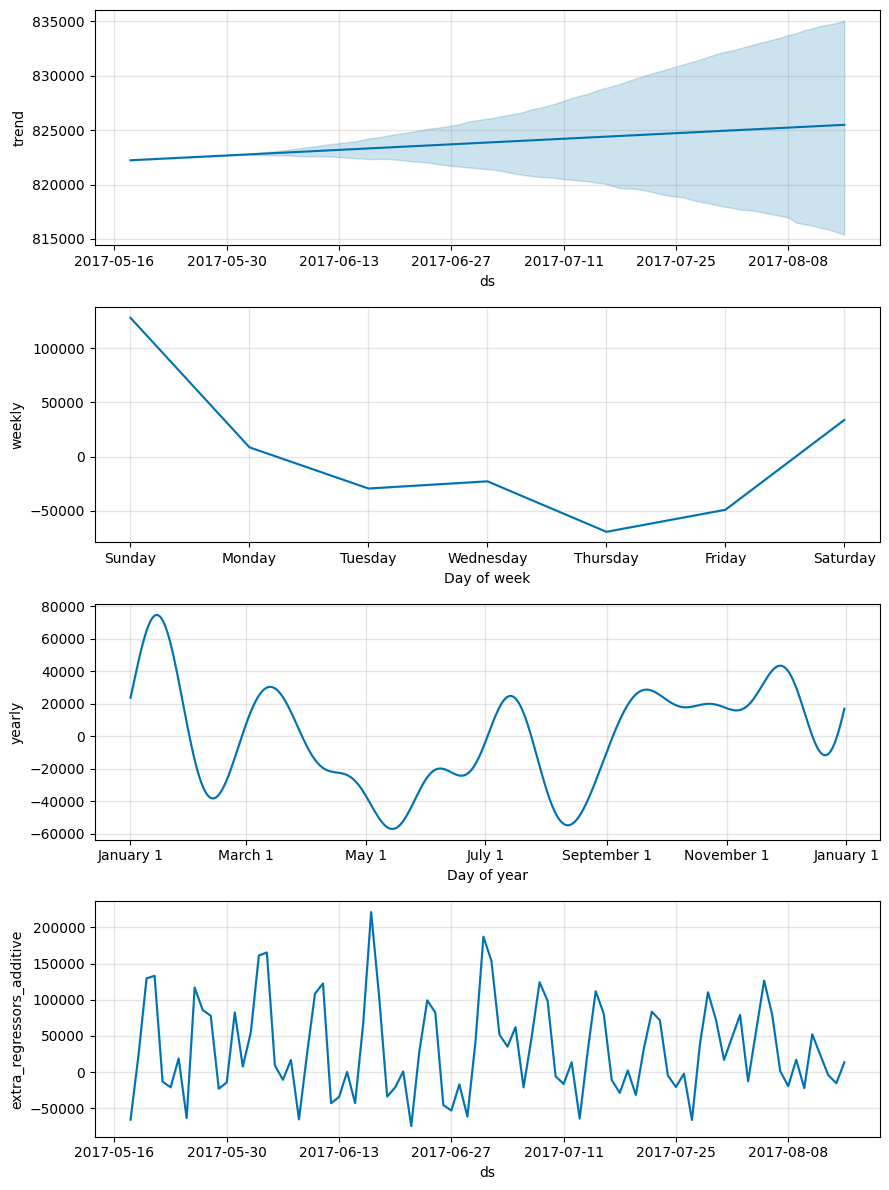

In [21]:
# Plot Prophet components

prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.show()

## Prophet Residual Diagnostics

This section creates a residual table and checks whether Prophet is systematically underpredicting or overpredicting certain periods.

In [22]:
# Create Prophet residual diagnostics table

prophet_diagnostics_df = valid_df[["date", "total_sales"]].copy()
prophet_diagnostics_df["prophet_pred"] = prophet_pred
prophet_diagnostics_df["residual"] = prophet_diagnostics_df["total_sales"] - prophet_diagnostics_df["prophet_pred"]
prophet_diagnostics_df["absolute_error"] = prophet_diagnostics_df["residual"].abs()
prophet_diagnostics_df["absolute_percentage_error"] = (
    prophet_diagnostics_df["absolute_error"] / prophet_diagnostics_df["total_sales"].replace(0, np.nan)
) * 100

prophet_diagnostics_df.head()

,date,total_sales,prophet_pred,residual,absolute_error,absolute_percentage_error
1564,2017-05-18,6.284880e+05,6.322272e+05,-3739.178441,3739.178441,0.594948
1565,2017-05-19,7.737754e+05,7.433830e+05,30392.434785,30392.434785,3.927811
1566,2017-05-20,1.035667e+06,9.336161e+05,102051.307247,102051.307247,9.853676
1567,2017-05-21,1.201939e+06,1.033110e+06,168829.346724,168829.346724,14.046417
1568,2017-05-22,7.789352e+05,7.694364e+05,9498.796146,9498.796146,1.219459


# Summarize Prophet residuals

prophet_diagnostics_df[["residual", "absolute_error", "absolute_percentage_error"]].describe()

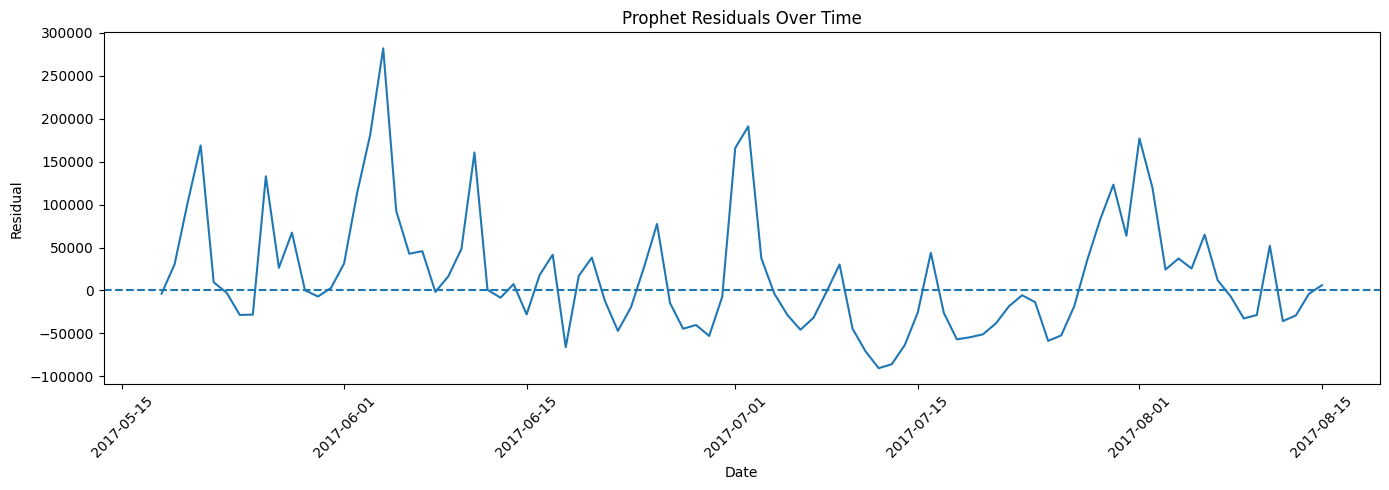

In [23]:
# Plot Prophet residuals over time

plt.figure(figsize=(14, 5))
plt.plot(prophet_diagnostics_df["date"], prophet_diagnostics_df["residual"])
plt.axhline(0, linestyle="--")
plt.title("Prophet Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

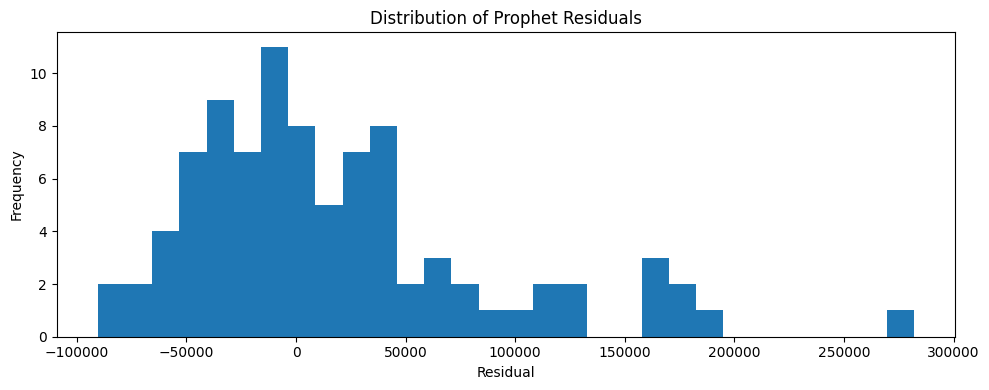

In [24]:
# Plot Prophet residual distribution

plt.figure(figsize=(10, 4))
plt.hist(prophet_diagnostics_df["residual"], bins=30)
plt.title("Distribution of Prophet Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Worst Forecast Errors

This section identifies the dates with the largest Prophet forecast misses.

In [25]:
# Show worst Prophet forecast errors

worst_prophet_errors = prophet_diagnostics_df.sort_values("absolute_error", ascending=False).head(10)

worst_prophet_errors

,date,total_sales,prophet_pred,residual,absolute_error,absolute_percentage_error
1581,2017-06-04,1.376512e+06,1.094612e+06,281899.692717,281899.692717,20.479283
1609,2017-07-02,1.296379e+06,1.105358e+06,191021.156399,191021.156399,14.734975
1580,2017-06-03,1.176138e+06,9.951440e+05,180994.136515,180994.136515,15.388851
1639,2017-08-01,9.885278e+05,8.115236e+05,177004.211901,177004.211901,17.905841
1567,2017-05-21,1.201939e+06,1.033110e+06,168829.346724,168829.346724,14.046417
1608,2017-07-01,1.207530e+06,1.041710e+06,165819.715457,165819.715457,13.732141
1588,2017-06-11,1.213674e+06,1.053042e+06,160631.824996,160631.824996,13.235171
1572,2017-05-26,9.845112e+05,8.515853e+05,132925.844009,132925.844009,13.501710
1637,2017-07-30,1.123752e+06,1.000602e+06,123149.986666,123149.986666,10.958818
1640,2017-08-02,9.647120e+05,8.453357e+05,119376.345468,119376.345468,12.374299


## Prophet Tuning

This section compares a few Prophet configurations to check whether the current model can be improved further.

In [26]:
# Define Prophet tuning helper

def run_prophet_model(train_data, valid_data, prophet_features, model_name,
                      seasonality_mode="additive",
                      changepoint_prior_scale=0.05,
                      seasonality_prior_scale=10.0):
    
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode=seasonality_mode,
        changepoint_prior_scale=changepoint_prior_scale,
        seasonality_prior_scale=seasonality_prior_scale
    )
    
    for col in prophet_features:
        model.add_regressor(col)
    
    model.fit(train_data)
    
    forecast = model.predict(valid_data.drop(columns=["y"]))
    pred = forecast["yhat"].values
    
    results = evaluate_forecast(valid_data["y"].values, pred, model_name)
    
    return model, forecast, pred, results

In [27]:
# Train tuned Prophet configurations

model_1, forecast_1, pred_1, results_1 = run_prophet_model(
    prophet_train,
    prophet_valid,
    prophet_features,
    model_name="prophet_default_like",
    seasonality_mode="additive",
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0
)

model_2, forecast_2, pred_2, results_2 = run_prophet_model(
    prophet_train,
    prophet_valid,
    prophet_features,
    model_name="prophet_more_flexible",
    seasonality_mode="additive",
    changepoint_prior_scale=0.20,
    seasonality_prior_scale=15.0
)

model_3, forecast_3, pred_3, results_3 = run_prophet_model(
    prophet_train,
    prophet_valid,
    prophet_features,
    model_name="prophet_multiplicative",
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.10,
    seasonality_prior_scale=10.0
)

prophet_tuning_results = pd.concat(
    [results_1, results_2, results_3],
    ignore_index=True
).sort_values("rmse")

prophet_tuning_results

00:00:32 - cmdstanpy - INFO - Chain [1] start processing
00:00:33 - cmdstanpy - INFO - Chain [1] done processing
00:00:33 - cmdstanpy - INFO - Chain [1] start processing
00:00:34 - cmdstanpy - INFO - Chain [1] done processing
00:00:35 - cmdstanpy - INFO - Chain [1] start processing
00:00:35 - cmdstanpy - INFO - Chain [1] done processing


,model,mae,rmse,mape
2,prophet_multiplicative,51598.263671,62955.223357,5.942615
1,prophet_more_flexible,53538.724862,68885.254196,6.193390
0,prophet_default_like,50123.703649,71571.140724,5.442261


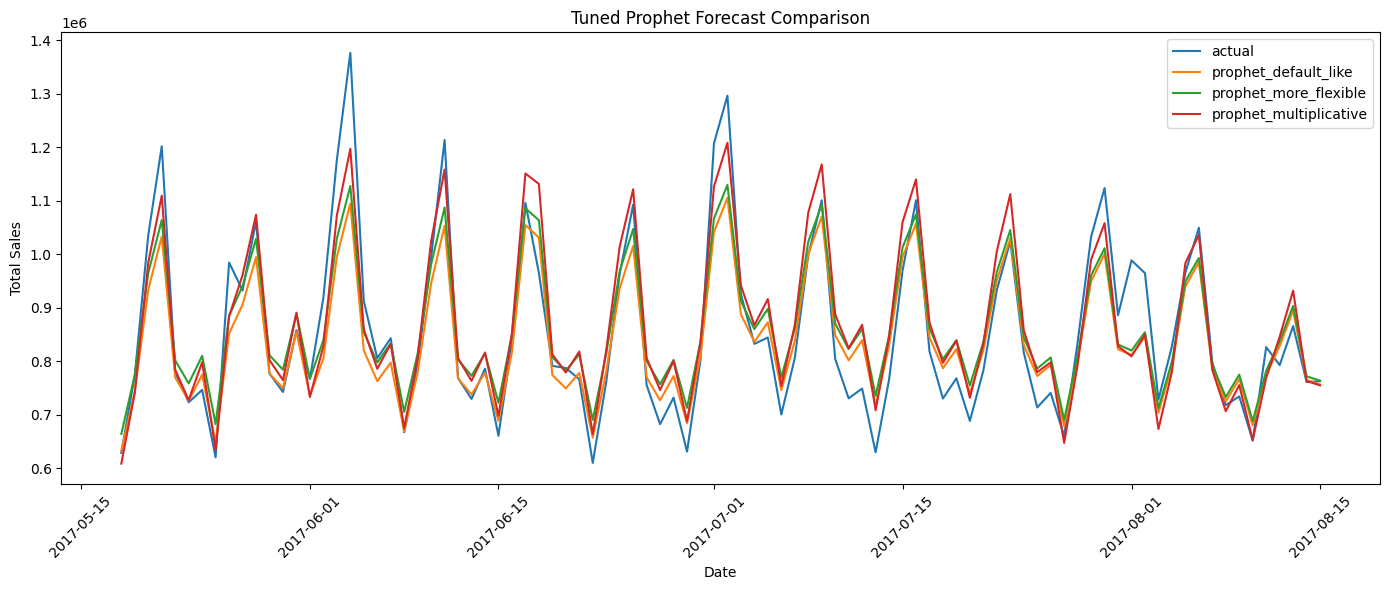

In [28]:
# Plot tuned Prophet forecasts

plot_prophet_df = valid_df[["date", "total_sales"]].copy()
plot_prophet_df["prophet_default_like"] = pred_1
plot_prophet_df["prophet_more_flexible"] = pred_2
plot_prophet_df["prophet_multiplicative"] = pred_3

plt.figure(figsize=(14, 6))
plt.plot(plot_prophet_df["date"], plot_prophet_df["total_sales"], label="actual")
plt.plot(plot_prophet_df["date"], plot_prophet_df["prophet_default_like"], label="prophet_default_like")
plt.plot(plot_prophet_df["date"], plot_prophet_df["prophet_more_flexible"], label="prophet_more_flexible")
plt.plot(plot_prophet_df["date"], plot_prophet_df["prophet_multiplicative"], label="prophet_multiplicative")
plt.title("Tuned Prophet Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Updated Prophet Benchmark

This section checks whether tuning improved Prophet and identifies the version that machine learning models will need to beat.

In [29]:
# Identify best Prophet version

prophet_tuning_results

,model,mae,rmse,mape
2,prophet_multiplicative,51598.263671,62955.223357,5.942615
1,prophet_more_flexible,53538.724862,68885.254196,6.193390
0,prophet_default_like,50123.703649,71571.140724,5.442261


RMSE is about:

62955

But your daily sales are often around:

700,000 to 1,300,000

from the validation plot.

So an RMSE around 63k is roughly in the ballpark of a single-digit percentage error scale, which is not terrible at all.

## Save Baseline and Time Series Outputs

This section saves model results and validation forecasts for later comparison with machine learning models.

In [30]:
# Save baseline and time series outputs

all_results.to_csv(PREDICTIONS_DIR / "baseline_time_series_results.csv", index=False)
plot_df.to_csv(PREDICTIONS_DIR / "baseline_time_series_validation_predictions.csv", index=False)

prophet_diagnostics_df.to_csv(PREDICTIONS_DIR / "prophet_diagnostics.csv", index=False)
worst_prophet_errors.to_csv(PREDICTIONS_DIR / "worst_prophet_errors.csv", index=False)
prophet_tuning_results.to_csv(PREDICTIONS_DIR / "prophet_tuning_results.csv", index=False)

print("Baseline and time series outputs saved successfully.")

Baseline and time series outputs saved successfully.


In [31]:
# Confirm saved prediction files

for file in PREDICTIONS_DIR.iterdir():
    print(file.name)

baseline_time_series_results.csv
baseline_time_series_validation_predictions.csv
prophet_diagnostics.csv
prophet_tuning_results.csv
worst_prophet_errors.csv


## Notebook Summary

This notebook built:

1. Naive baseline forecasts
2. Seasonal naive baseline forecasts
3. Moving-average baseline forecasts
4. A SARIMAX model with exogenous features
5. A Prophet model with external regressors
6. A clean validation comparison table

The next notebook will build machine learning forecasting models and compare them against these baseline and classical time series results.